In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('C:\\Users\\nmims.student\\CO2 Concentration.csv')
df.head()

,Year,Month,CO2 Concentration
0,1975,1,330.62
1,1975,2,331.40
2,1975,3,331.87
3,1975,4,333.18
4,1975,5,333.92


In [4]:
df['Date'] = pd.to_datetime(df[['Year','Month']].assign(Day=1))
df.head()

,Year,Month,CO2 Concentration,Date
0,1975,1,330.62,1975-01-01
1,1975,2,331.40,1975-02-01
2,1975,3,331.87,1975-03-01
3,1975,4,333.18,1975-04-01
4,1975,5,333.92,1975-05-01


In [5]:
df.drop(['Year','Month'], axis=1, inplace=True)

In [6]:
df

,CO2 Concentration,Date
0,330.62,1975-01-01
1,331.40,1975-02-01
2,331.87,1975-03-01
3,333.18,1975-04-01
4,333.92,1975-05-01
...,...,...
139,345.55,1986-08-01
140,344.21,1986-09-01
141,343.67,1986-10-01
142,345.09,1986-11-01


In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

In [8]:
df.head()

,CO2 Concentration
Date,
1975-01-01,330.62
1975-02-01,331.40
1975-03-01,331.87
1975-04-01,333.18
1975-05-01,333.92


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'CO2 Concentration')

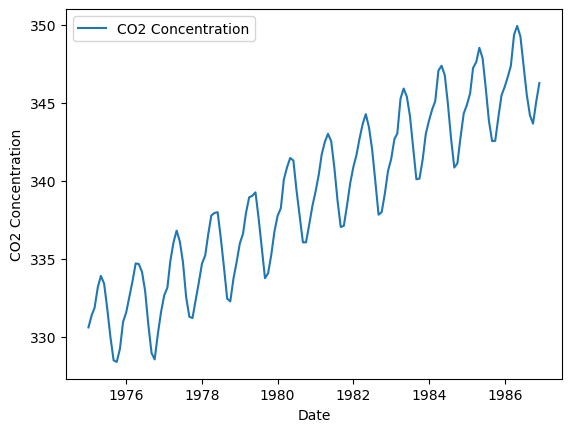

In [9]:
sns.lineplot(df)
plt.ylabel('CO2 Concentration')

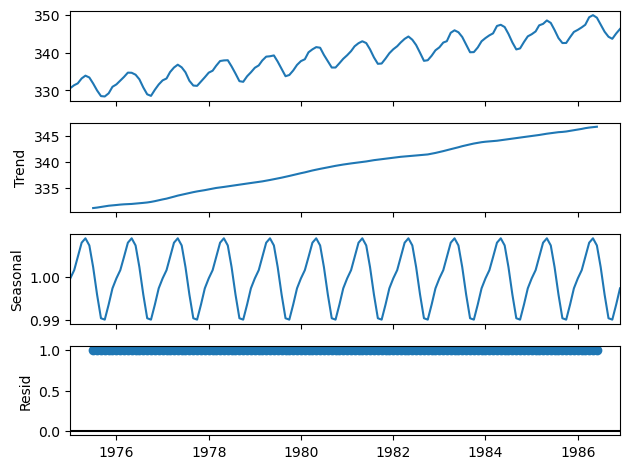

In [10]:
result = seasonal_decompose(df[['CO2 Concentration']], model='multiplicative')
result.plot()
plt.show()

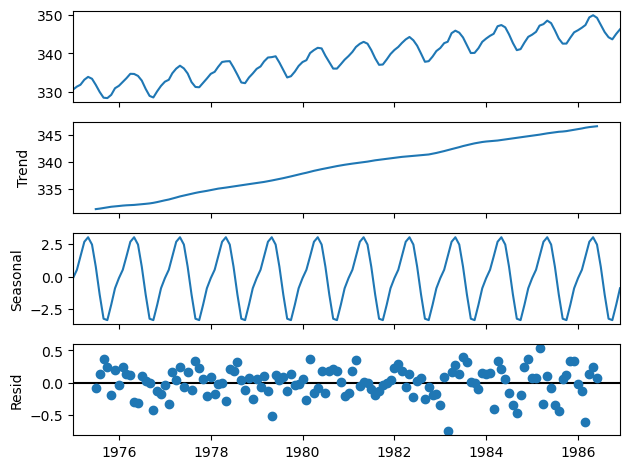

In [11]:
result = seasonal_decompose(df[['CO2 Concentration']], model='additive')
result.plot()
plt.show()

In [12]:
pip install pymannkendall

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [13]:
import pymannkendall as mk

#perform Mann-Kendall test
#H0: There is no monotonic trend in the series

mk.original_test(df['CO2 Concentration'])

Mann_Kendall_Test(trend='increasing', h=True, p=0.0, z=13.22737013469656, Tau=0.7438811188811189, s=7659.0, var_s=335184.3333333333, slope=0.11999999999999982, intercept=330.545)

In [14]:
#p-value<0.5 reject H0 there is a trend present
train_df = df[:int(df.shape[0]*0.7)]
test_df = df[int(df.shape[0]*0.7):]

In [15]:
train_df.shape

(100, 1)

In [16]:
#Triple Exponential Smoothing

from statsmodels.tsa.api import ExponentialSmoothing

model_triple = ExponentialSmoothing(train_df, seasonal_periods = 12, trend='add', seasonal='add')
model_triple_fit = model_triple.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [17]:
forecast_triple = model_triple_fit.forecast(6)
print(forecast_triple)

1983-05-01    345.256582
1983-06-01    344.890272
1983-07-01    343.350304
1983-08-01    341.355265
1983-09-01    339.605338
1983-10-01    339.580263
Freq: MS, dtype: float64


In [18]:
forecast_triple = model_triple_fit.forecast(40)
model_triple_fit.params

{'smoothing_level': 0.459159463627512,
 'smoothing_trend': 4.7420779464118886e-15,
 'smoothing_seasonal': 2.970077805307608e-15,
 'damping_trend': nan,
 'initial_level': 330.48496714327604,
 'initial_trend': 0.11765480568419205,
 'initial_seasons': array([-0.1351112 ,  0.5338958 ,  1.55177394,  2.62522281,  2.88837213,
         2.40440725,  0.74678469, -1.36590865, -3.23349047, -3.37622086,
        -2.2488242 , -1.02649119]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

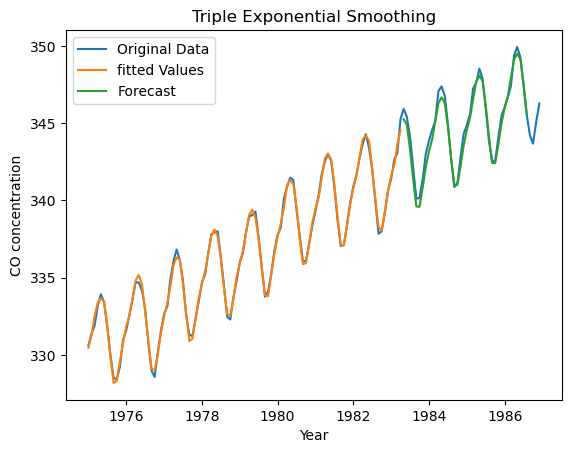

In [19]:
plt.plot(df,label='Original Data')
plt.plot(model_triple_fit.fittedvalues, label='fitted Values')
plt.plot(forecast_triple, label='Forecast')
plt.xlabel('Year')
plt.ylabel('CO concentration')
plt.title('Triple Exponential Smoothing')
plt.legend()
plt.show()

In [20]:
#Practical-2 Checking Stationary
#ADF Test
#h0-series is not stationary vs h1-series is stationary

In [21]:
from statsmodels.tsa.stattools import adfuller
print('Results of the Dickey Fuller Test:')
dftest = adfuller(df['CO2 Concentration'])
dfoutput=pd.Series(dftest[0:4],index=["Test Statistic",'P-value','#Lags used','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput['Critical Value(%s)' %key] =value
print(dfoutput)

Results of the Dickey Fuller Test:
Test Statistic             -0.612294
P-value                     0.868180
#Lags used                 14.000000
Number of Observations    129.000000
Critical Value(1%)         -3.482088
Critical Value(5%)         -2.884219
Critical Value(10%)        -2.578864
dtype: float64


In [22]:
#p-value>0.5 so we fail to reject the null hypothesis i.e Series is NOT stationary

In [23]:
#KPSS Test
#h0-series is stationary vs h1-series is not stationary

In [24]:
from statsmodels.tsa.stattools import kpss
kp = kpss(df['CO2 Concentration'])
p = kp[1]
print ("p-value for KPSS test (untransformed) = ", p)

p-value for KPSS test (untransformed) =  0.01


C:\Users\nmims.student\AppData\Local\Temp\ipykernel_13124\3940235174.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(df['CO2 Concentration'])


In [25]:
#p-value<0.5 so we fail to reject the null hypothesis i.e Series is NOT stationary

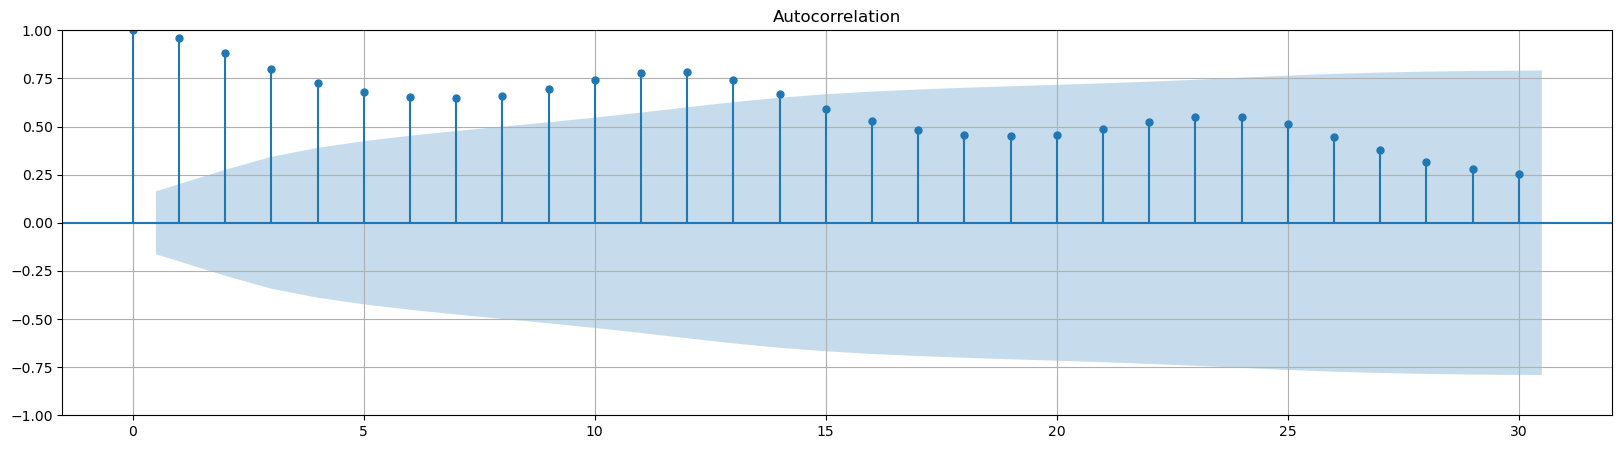

In [26]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(df['CO2 Concentration'], ax=plt.gca(), lags=30)
plt.show()

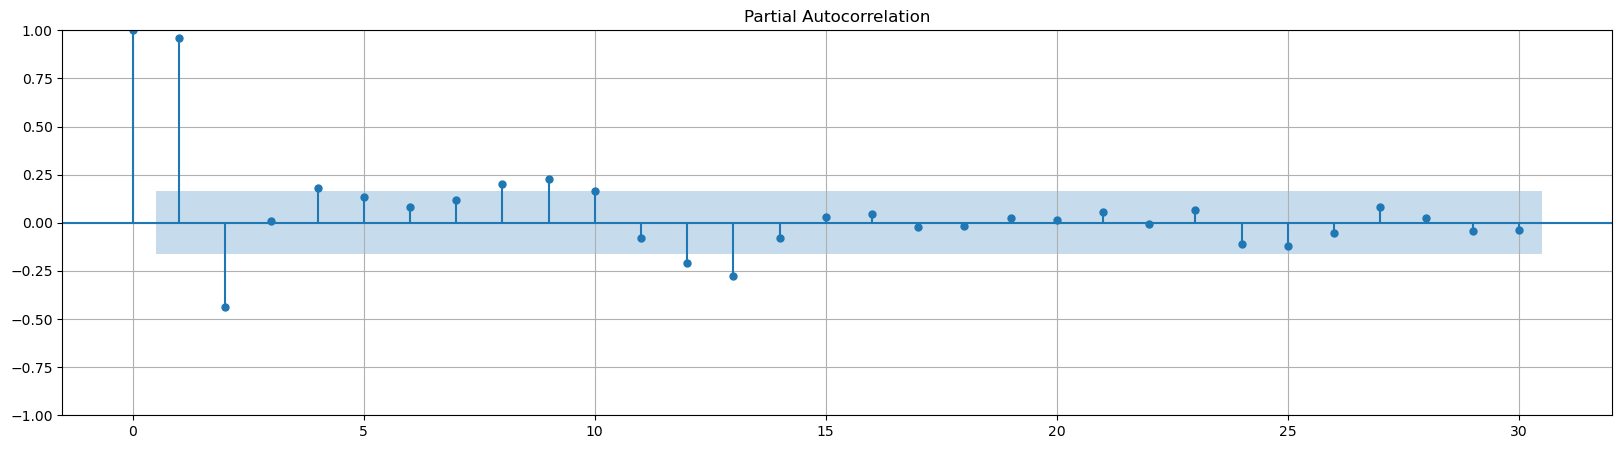

In [27]:
plt.figure(figsize=(20,5))
plt.grid()
plot_pacf(df['CO2 Concentration'], ax=plt.gca(), lags=30)
plt.show()

In [28]:
#To make the data stationary we do differencing

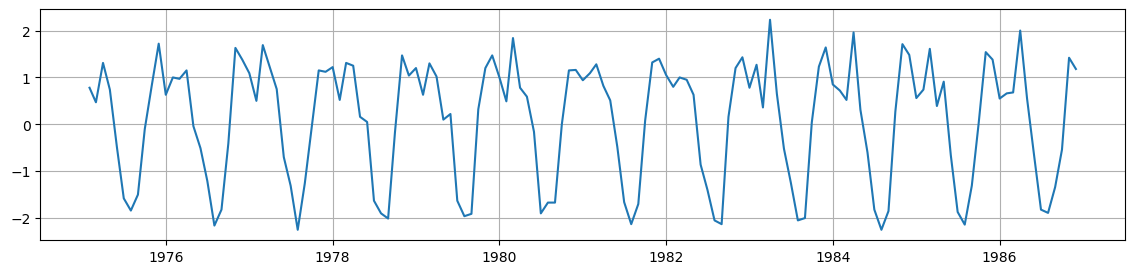

In [29]:
#First order non-seasonal differencing
diff = df['CO2 Concentration'].diff().dropna()
plt.figure(figsize=(14,3))
plt.grid()
plt.plot(diff)
plt.show()

In [30]:
kp = kpss(diff)
p = kp[1]
print ("p-value for KPSS test (untransformed) = ", p)
#KPSS tells it is stationary

p-value for KPSS test (untransformed) =  0.1


C:\Users\nmims.student\AppData\Local\Temp\ipykernel_13124\3101869230.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(diff)


In [31]:
print('Results of the Dickey Fuller Test:')
dftest = adfuller(diff)
dfoutput=pd.Series(dftest[0:4],index=["Test Statistic",'P-value','#Lags used','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput['Critical Value(%s)' %key] =value
print(dfoutput)
#ADF tells it is not stationary

Results of the Dickey Fuller Test:
Test Statistic             -2.651492
P-value                     0.082815
#Lags used                 13.000000
Number of Observations    129.000000
Critical Value(1%)         -3.482088
Critical Value(5%)         -2.884219
Critical Value(10%)        -2.578864
dtype: float64


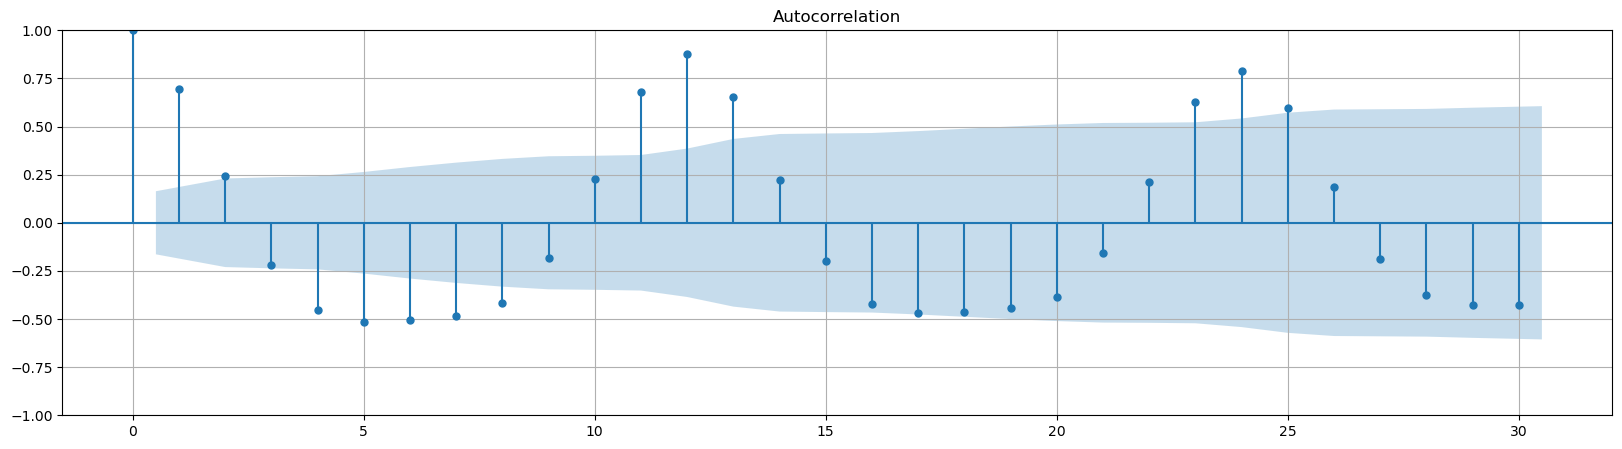

In [32]:
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(diff, ax=plt.gca(), lags=30)
plt.show()
#it is sigmoid and also doesn't lie inside significance therefore it is not stationary.

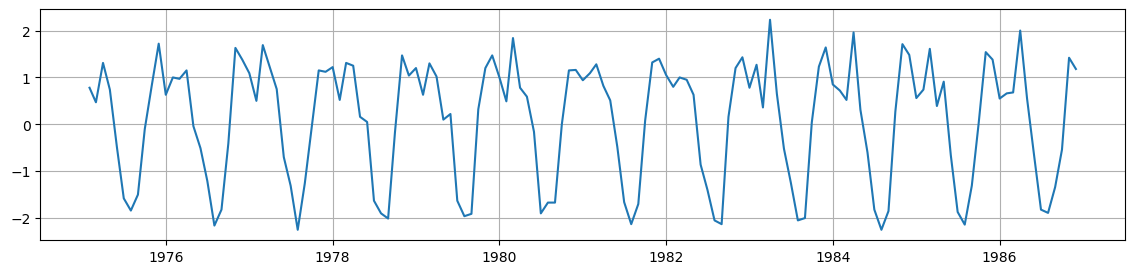

In [33]:
#Second order non-seasonal differencing
diff2 = df['CO2 Concentration'].diff().diff().dropna()
plt.figure(figsize=(14,3))
plt.grid()
plt.plot(diff)
plt.show()

In [34]:
print('Results of the Dickey Fuller Test:')
dftest = adfuller(diff2)
dfoutput=pd.Series(dftest[0:4],index=["Test Statistic",'P-value','#Lags used','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput['Critical Value(%s)' %key] =value
print(dfoutput)
#ADF tells it is not stationary

Results of the Dickey Fuller Test:
Test Statistic           -1.034872e+01
P-value                   2.570048e-18
#Lags used                1.200000e+01
Number of Observations    1.290000e+02
Critical Value(1%)       -3.482088e+00
Critical Value(5%)       -2.884219e+00
Critical Value(10%)      -2.578864e+00
dtype: float64


In [35]:
kp = kpss(diff2)
p = kp[1]
print ("p-value for KPSS test (untransformed) = ", p)
#KPSS tells it is stationary

p-value for KPSS test (untransformed) =  0.1


C:\Users\nmims.student\AppData\Local\Temp\ipykernel_13124\1232017485.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(diff2)


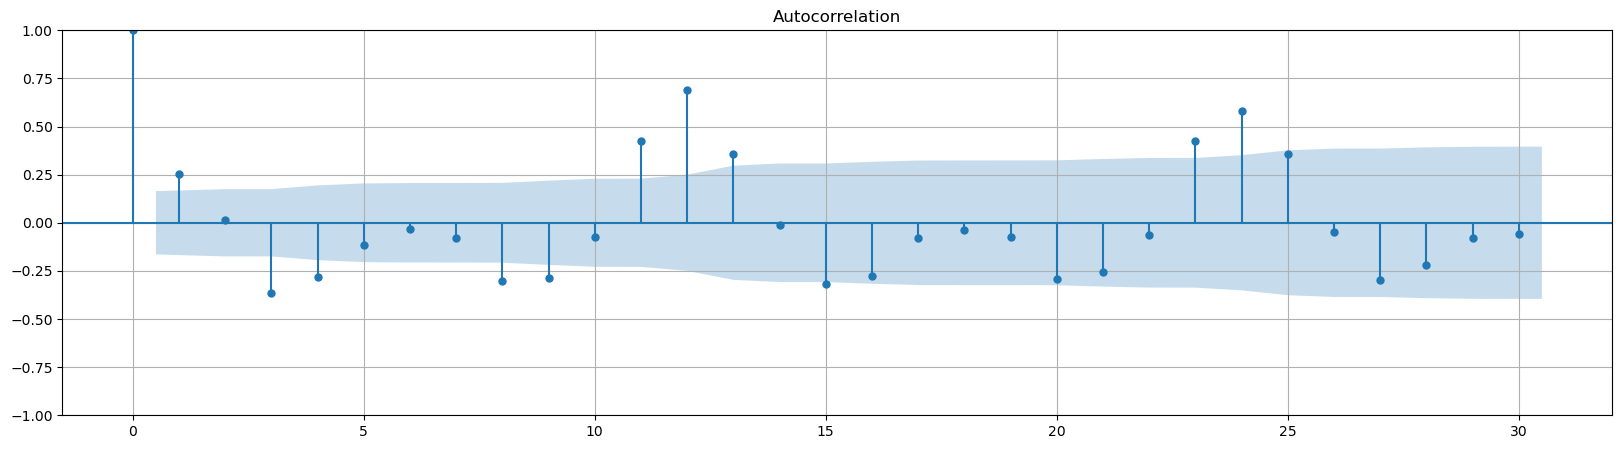

In [36]:
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(diff2, ax=plt.gca(), lags=30)
plt.show()
#it is sigmoid and also doesn't lie inside significance therefore it is not stationary.

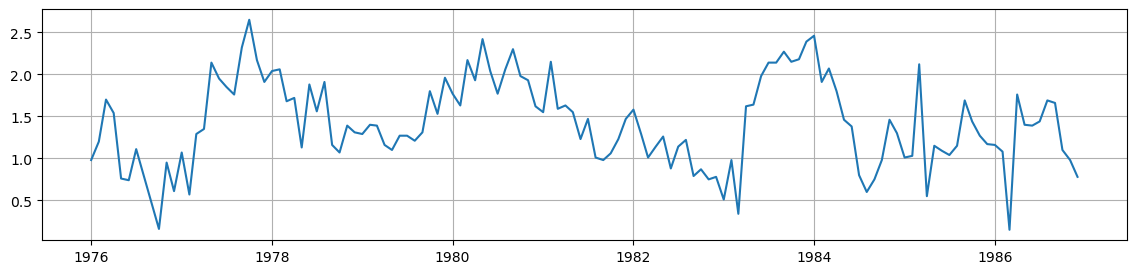

In [37]:
#First order Seasonal differencing
sdiff = df['CO2 Concentration'].diff(periods = 12).dropna()
plt.figure(figsize=(14,3))
plt.grid()
plt.plot(sdiff)
plt.show()

In [38]:
print('Results of the Dickey Fuller Test:')
dftest = adfuller(sdiff)
dfoutput=pd.Series(dftest[0:4],index=["Test Statistic",'P-value','#Lags used','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput['Critical Value(%s)' %key] =value
print(dfoutput)
#series is stationary

Results of the Dickey Fuller Test:
Test Statistic             -3.329692
P-value                     0.013602
#Lags used                 13.000000
Number of Observations    118.000000
Critical Value(1%)         -3.487022
Critical Value(5%)         -2.886363
Critical Value(10%)        -2.580009
dtype: float64


In [39]:
kp = kpss(sdiff)
p = kp[1]
print ("p-value for KPSS test (untransformed) = ", p)
#series is stationary

p-value for KPSS test (untransformed) =  0.1


C:\Users\nmims.student\AppData\Local\Temp\ipykernel_13124\3086954030.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(sdiff)


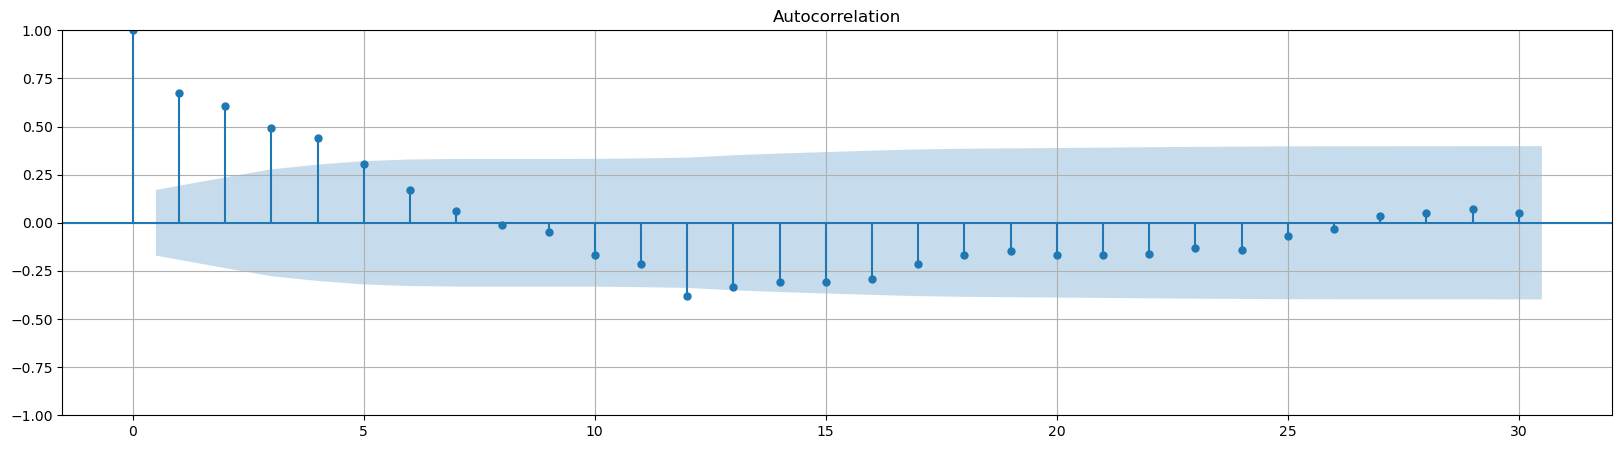

In [40]:
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(sdiff, ax=plt.gca(), lags=30)
plt.show()

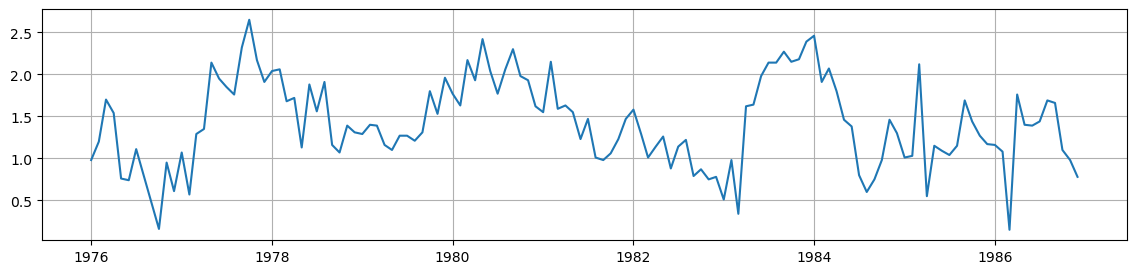

In [41]:
#Seasonal and NON-Seasonal differencing
sdiff = df['CO2 Concentration'].diff(periods = 12).dropna()
sddiff = sdiff.diff().dropna()
plt.figure(figsize=(14,3))
plt.grid()
plt.plot(sdiff)
plt.show()

In [42]:
print('Results of the Dickey Fuller Test:')
dftest = adfuller(sddiff)
dfoutput=pd.Series(dftest[0:4],index=["Test Statistic",'P-value','#Lags used','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput['Critical Value(%s)' %key] =value
print(dfoutput)
#series is stationary

Results of the Dickey Fuller Test:
Test Statistic             -4.848142
P-value                     0.000044
#Lags used                 12.000000
Number of Observations    118.000000
Critical Value(1%)         -3.487022
Critical Value(5%)         -2.886363
Critical Value(10%)        -2.580009
dtype: float64


In [43]:
kp = kpss(sddiff)
p = kp[1]
print ("p-value for KPSS test (untransformed) = ", p)
#series is stationary

p-value for KPSS test (untransformed) =  0.1


C:\Users\nmims.student\AppData\Local\Temp\ipykernel_13124\1755925953.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(sddiff)


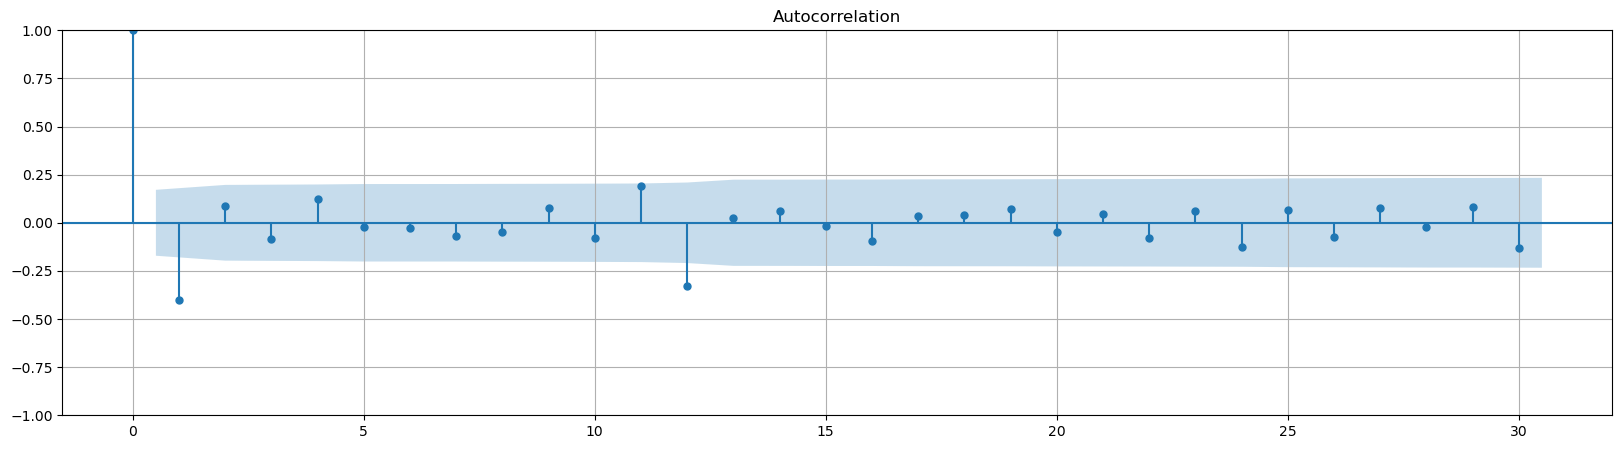

In [44]:
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(sddiff, ax=plt.gca(), lags=30)
plt.show()
#series is stationary

In [45]:
import statsmodels.api as sm
model_1 =sm.tsa.statespace.SARIMAX(train_df['CO2 Concentration'], order=(1,1,1),seasonal_order=(1,1,1,12))
model_1_fit = model_1.fit()

print(model_1_fit.summary())

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                  CO2 Concentration   No. Observations:                  100
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -17.824
Date:                            Mon, 10 Feb 2025   AIC                             45.649
Time:                                    12:10:58   BIC                             57.978
Sample:                                01-01-1975   HQIC                            50.614
                                     - 04-01-1983                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3863      0.179     -2.157      0.031      -0.737      -0.035
ma.L1         -0.2661      0.187   

In [47]:
from pmdarima.arima import auto_arima
model_auto_arima = auto_arima(df['CO2 Concentration'], seasonal = True, trace = True, m = 12)
model_auto_arima = model_auto_arima.fit(df['CO2 Concentration'])

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=0.75 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=204.499, Time=0.05 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=107.753, Time=0.31 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=0.42 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=485.686, Time=0.02 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=125.174, Time=0.08 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=97.033, Time=0.66 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=1.04 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.48 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=161.399, Time=0.39 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=84.543, Time=0.86 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=96.302, Time=0.40 sec
 ARIMA(2,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=1.03 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.61 sec
 ARIMA(3,0,0)(2,1,0)[12] intercept   : AIC=84.846, Time=1.14

In [48]:
model_2 =sm.tsa.statespace.SARIMAX(train_df['CO2 Concentration'], order=(1,0,1),seasonal_order=(2,1,1,12))
model_2_fit = model_2.fit()
print(model_2_fit.summary())

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                  CO2 Concentration   No. Observations:                  100
Model:             SARIMAX(1, 0, 1)x(2, 1, 1, 12)   Log Likelihood                 -21.359
Date:                            Mon, 10 Feb 2025   AIC                             54.718
Time:                                    12:13:34   BIC                             69.582
Sample:                                01-01-1975   HQIC                            60.707
                                     - 04-01-1983                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.001   1676.895      0.000       0.999       1.001
ma.L1         -0.5231      0.094   

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [49]:
test_prediction1 = model_1_fit.forecast(len(test_df))
forcast_further1 = model_1_fit.forecast(len(test_df['CO2 Concentration'])+10)
forcast_further1 = forcast_further1[test_df.index.max():]
forcast_further1

1986-12-01    346.340302
1987-01-01    347.342984
1987-02-01    348.131008
1987-03-01    349.262964
1987-04-01    350.457026
1987-05-01    350.816437
1987-06-01    350.476259
1987-07-01    348.925758
1987-08-01    346.935059
1987-09-01    345.183268
1987-10-01    345.158509
Freq: MS, Name: predicted_mean, dtype: float64

In [50]:
test_prediction2 = model_2_fit.forecast(len(test_df))
forcast_further2 = model_2_fit.forecast(len(test_df['CO2 Concentration'])+10)
forcast_further2 = forcast_further2[test_df.index.max():]
forcast_further2

1986-12-01    346.182409
1987-01-01    347.176096
1987-02-01    347.978963
1987-03-01    349.072682
1987-04-01    350.294465
1987-05-01    350.671151
1987-06-01    350.283565
1987-07-01    348.744290
1987-08-01    346.747423
1987-09-01    344.988226
1987-10-01    344.965191
Freq: MS, Name: predicted_mean, dtype: float64

In [51]:
from sklearn.metrics import mean_absolute_percentage_error
mape_test1 = mean_absolute_percentage_error(test_df['CO2 Concentration'],test_prediction1)
print(mape_test1)

0.00114545808791164


In [52]:
mape_test2 = mean_absolute_percentage_error(test_df['CO2 Concentration'],test_prediction2)
print(mape_test2)

0.0013175193426119035


<function matplotlib.pyplot.show(close=None, block=None)>

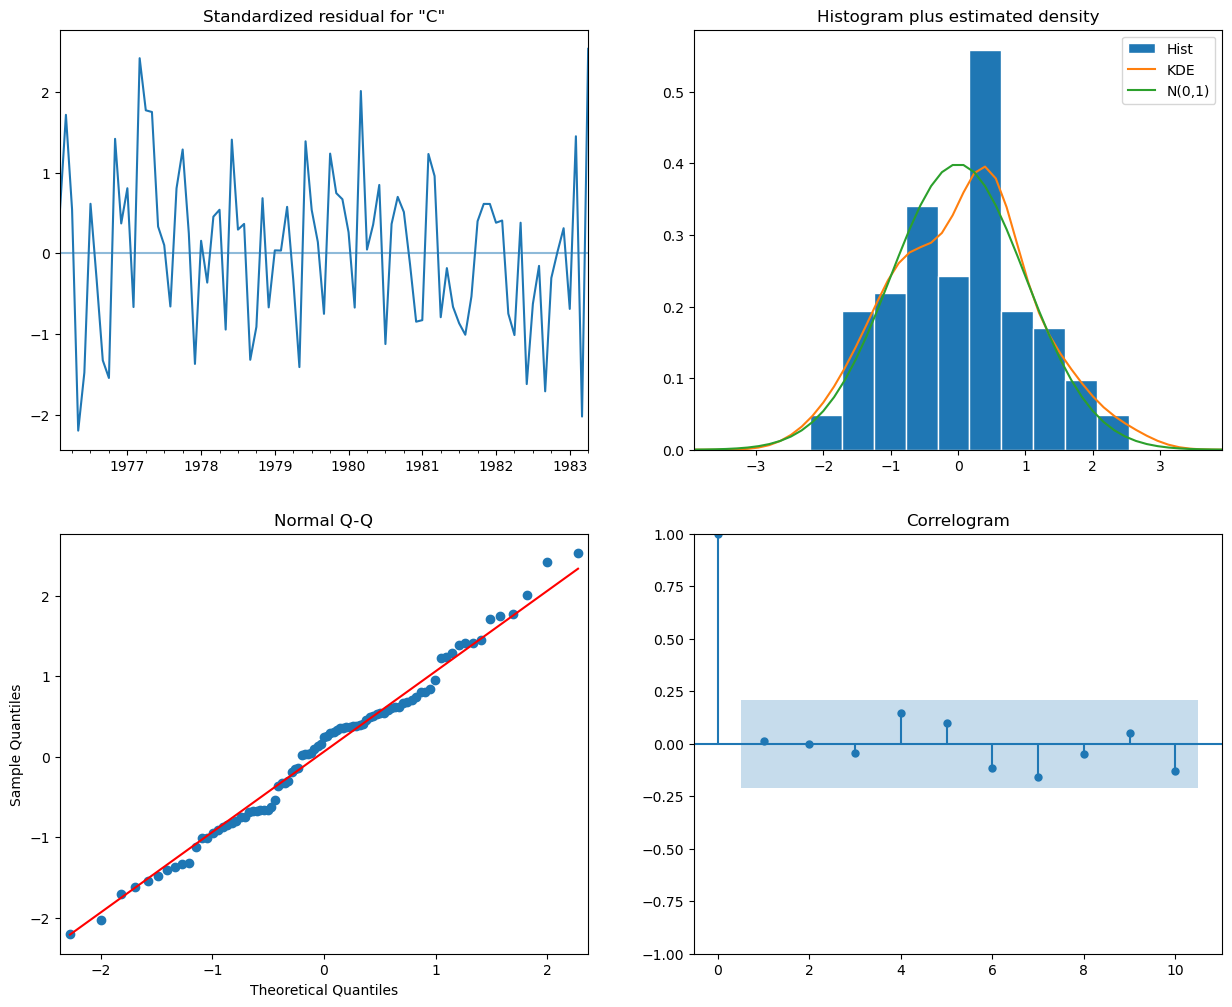

In [53]:
model_1_fit.plot_diagnostics(figsize=(15,12))
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

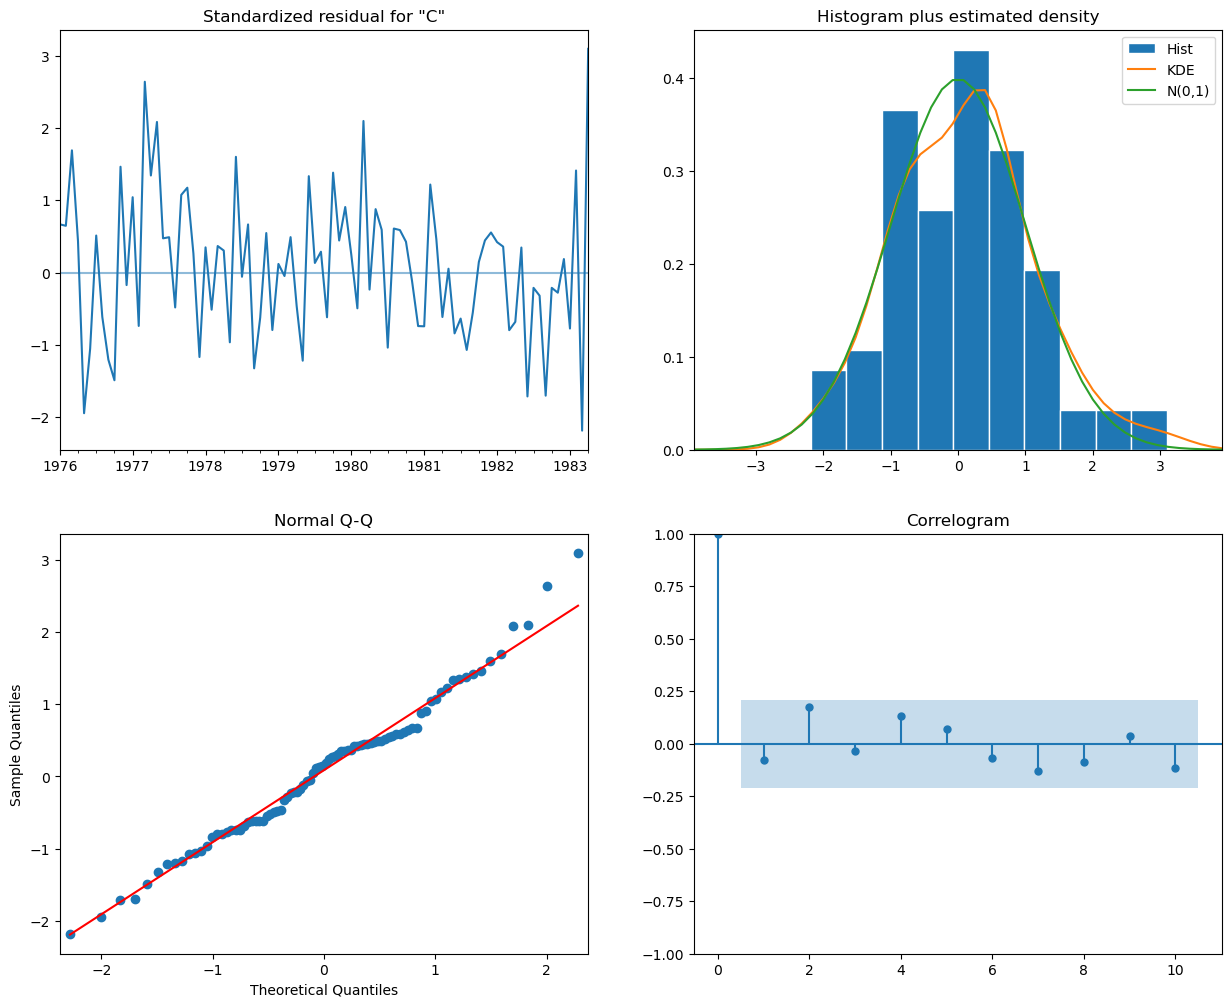

In [54]:
model_2_fit.plot_diagnostics(figsize=(15,12))
plt.show

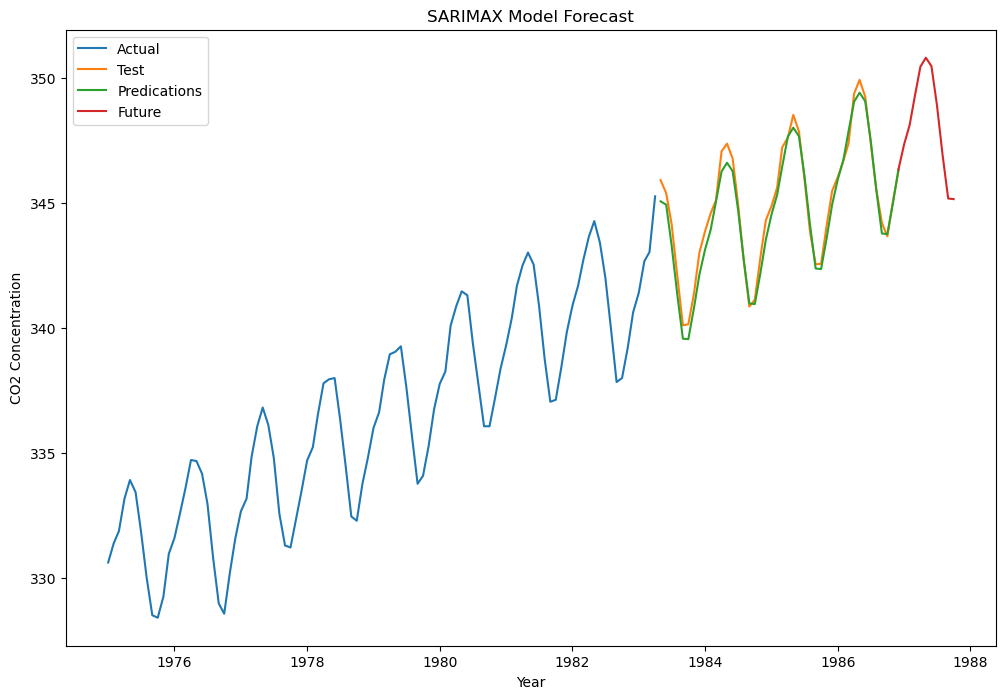

In [56]:
plt.figure(figsize=(12,8))
plt.plot(train_df['CO2 Concentration'],label='Actual')
plt.plot(test_df['CO2 Concentration'],label='Test')
plt.plot(test_prediction1,label='Predications')
plt.plot(forcast_further1,label='Future')
plt.title('SARIMAX Model Forecast')
plt.xlabel('Year')
plt.ylabel('CO2 Concentration')
plt.legend()
plt.show()